In [1]:
import sys, os, pickle
print(sys.version)
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("error", category=RuntimeWarning)

3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]


In [20]:
train = pd.read_csv(os.path.join("data", "sign_mnist_train.csv"))
print(train.shape)
train.head()

(27455, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [21]:
y_col = "label"
X = (
    train
    .drop(y_col, axis=1)
    .to_numpy()
    .astype(np.int16) # Downcast to save memory 
)
y = train[y_col].to_numpy().astype(np.int8)

def one_hot(data, uniques=None):
    if uniques is None:
        uniques = np.unique(data)
    _data = np.squeeze(data)[:, np.newaxis] # Enforce as column vector
    _labels = np.squeeze(uniques)[np.newaxis] # Enforce as row vector
    return _data == _labels    

possible_labels = np.unique(y)
Y = one_hot(y, possible_labels)
print(X.shape, Y.shape)
del train

(27455, 784) (27455, 24)


In [31]:
subset = y <= 2
X_ = X[subset]
Y_ = Y[subset, :3]
toy_labels = [0, 1, 2]
print(X_.shape, Y_.shape)

(3280, 784) (3280, 3)


C:\Users\archi\AppData\Local\Temp\ipykernel_13432\1939488016.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  samples = np.array([


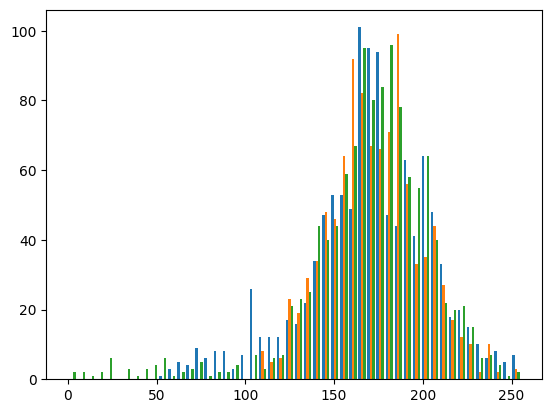

In [5]:
samples = np.array([
    X_[y[subset]==label, 250]
    for label in [0, 1, 2]
])
plt.hist(samples.T, bins=50)
plt.show()

In [6]:
def entropy(freqs, eps=1e-10):
    _sums = np.sum(freqs, axis=-1, keepdims=True)
    p = np.array(freqs) / np.maximum(_sums, eps)
    return -1. * np.sum(
        p * np.log2(np.maximum(p, eps)),
        axis = -1
    )

def conditional_entropy(freqs):
    shares = np.sum(freqs, axis=-1, keepdims=True)
    _sums = np.sum(
        shares, 
        axis = -min(2, np.ndim(shares)),
        keepdims=True
    )
    shares = shares / _sums
    entropies = entropy(freqs)
    if np.ndim(shares) > 2:
        cond_entr = [
            entr.dot(s)
            for entr, s in zip(entropies, shares)
        ]
    else:
        cond_entr = np.dot(entropies, shares)
    return np.squeeze(cond_entr)

In [7]:
a = [20, 10]
b = [10, 0]
c = [15, 7]
d = [15, 3]
print(entropy(a))
print(entropy(b))
print(entropy([a, b]))
print(entropy([
    [a, b],
    [c, d]
]))

print(conditional_entropy([a, b]))
print(conditional_entropy([c, d]))
print(conditional_entropy([
    [a, b],
    [c, d],
    [a, b],
    [c, d]
]))

0.9182958340544896
-0.0
[ 0.91829583 -0.        ]
[[ 0.91829583 -0.        ]
 [ 0.90239328  0.65002242]]
0.6887218755408672
0.7888263952789978
[0.68872188 0.7888264  0.68872188 0.7888264 ]


## Decision tree implementation

In [8]:
SPLITS_TO_TEST = np.arange(X.min().min(), X.max().max()) + 0.5
SPLITS_TO_TEST[[0, -1]]

array([  0.5, 254.5])

In [92]:
class TreeClassifier():

    def __init__(self, 
                 classes: np.ndarray,
                 max_depth: int = 1,
                 min_samples_per_leaf: int = 1):
        self.classes = classes
        self.max_depth = max_depth
        self.min_samples_per_leaf = min_samples_per_leaf

    def get_split_result(self, x_vec, boundary, y_matrix):
        test = x_vec <= boundary
        return np.array([
            y_matrix[test].sum(0),
            y_matrix[~test].sum(0)
        ])
        
    def single_feature_best_split(self, 
                                  x_vec, 
                                  y_matrix,
                                  splits = SPLITS_TO_TEST,
                                  return_entropies: bool = False,
                                  **kwargs):
        _splits = np.array([
            self.get_split_result(x_vec, s, y_matrix)
            for s in splits
        ])
        conditional_entropies = conditional_entropy(_splits)
        argmin = np.argmin(conditional_entropies)
        best = splits[argmin]
        if return_entropies:
            return argmin, best, conditional_entropies
        else:
            return argmin, best
        
    def all_features_best_split(self, 
                                X, 
                                y_matrix,
                                splits = SPLITS_TO_TEST,
                                return_entropies: bool = False,
                                **kwargs):
        d = X.shape[1]
        argmins = np.inf * np.ones(d)
        entropies = -1. * np.ones((d, len(splits)))
        for i in range(d):
            argmins[i], _, entropies[i] = self.single_feature_best_split(
                x_vec = X[:, i],
                y_matrix = y_matrix,
                splits = splits,
                return_entropies = True
            )
        argmins = argmins.astype(int)
        min_entropies = entropies[np.arange(d), argmins]
        feature_to_use = np.argmin(min_entropies)
        boundary_to_use = splits[argmins[feature_to_use]]
        if return_entropies:
            return feature_to_use, boundary_to_use, entropies
        else:
            return feature_to_use, boundary_to_use

    def fit(self, X, y_matrix, **kwargs):
        self.branches = None
        self.frequencies = y_matrix.sum(0)
        if self.max_depth > 0:
            n = X.shape[0]
            if n > (threshold := self.min_samples_per_leaf):
                self.feature, self.boundary = self.all_features_best_split(
                    X = X,
                    y_matrix = y_matrix,
                    **kwargs
                )
                test = X[:, self.feature] <= self.boundary
                sufficient = lambda arr: arr.sum() >= threshold
                if sufficient(test) and sufficient(~test):
                    self.branches = []
                    for subset in [~test, test]:
                        branch = TreeClassifier(
                            classes = self.classes,
                            max_depth = self.max_depth - 1,
                            min_samples_per_leaf = self.min_samples_per_leaf
                        )
                        branch.fit(X[subset], y_matrix[subset], **kwargs)
                        self.branches.append(branch)

    def predict_proba(self, X, **kwargs):
        if np.ndim(X) == 1:
            X = X[np.newaxis] # Enforce row-vector format
        n = X.shape[0]
        if self.branches is None:
            freqs = self.frequencies / self.frequencies.sum()
            probs = np.array([freqs for _ in range(n)])
        else:
            probs = -1. * np.ones((n, len(self.classes)))
            above_threshold = X[:, self.feature] <= self.boundary
            for case, branch in enumerate(self.branches):
                select = above_threshold == case
                if sum(select) > 0:
                    probs[select] = branch.predict_proba(X[select], **kwargs)
            assert np.all(probs >= 0), f"predict_proba failed!"
        return probs
    
    def predict(self, X, **kwargs):
        probs = self.predict_proba(X, **kwargs)
        return self.classes[np.argmax(probs, axis=-1).astype(int)]


tree = TreeClassifier(
    classes = np.array(toy_labels),
    max_depth = 3
)
toy_X = X_[:, :20]
#tree.fit(toy_X, Y_)
#preds = tree.predict(toy_X)
#preds

In [74]:
test_x_vec = X_[:, 0]
print(tree.get_split_result(
    x_vec = test_x_vec,
    boundary = 221.5,
    y_matrix = Y_
))

[[1088 1002 1106]
 [  38    8   38]]


Best split: 182.5


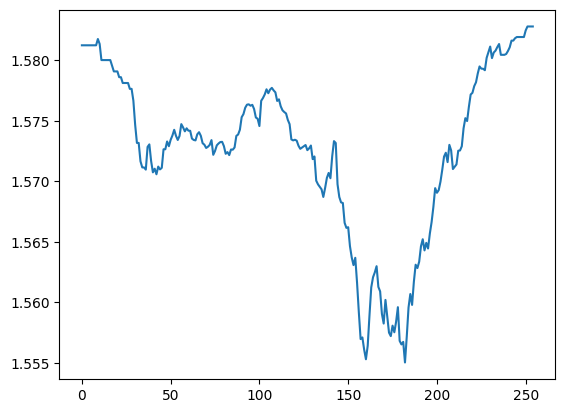

In [76]:
_, best, cond_entr = tree.single_feature_best_split(
    x_vec = test_x_vec,
    y_matrix = Y_,
    return_entropies = True
)
print(f"Best split: {best}")
plt.plot(cond_entr)
plt.show()

In [120]:
feature_to_use, boundary_to_use = tree.all_features_best_split(
    X = X_[:, :200],
    y_matrix = Y_
)
feature_to_use, boundary_to_use

(183, 94.5)

## Random Forest implementation

In [93]:
class RandomForestClassifier():

    def __init__(self,
                 classes: np.ndarray,
                 n_trees: int = 10,
                 share_obs: float = .2,
                 share_features: float = .2,
                 *args, **kwargs):
        self.classes = classes
        assert 0 < share_obs <= 1
        self.share_obs = share_obs
        assert 0 < share_features <= 1
        self.share_features = share_features
        self.n_trees = n_trees
        self.tree_args = kwargs
        self.trees = [
            TreeClassifier(classes=classes, **kwargs)
            for _ in range(n_trees)
        ]
        self.features = [None for _ in range(n_trees)]

    def bootstrap_dims(self, n, d):        
        sample_size = int(round(max(1, n * self.share_obs)))
        n_features = int(round(max(1, d * self.share_features)))
        return sample_size, n_features

    def fit_single_tree(self,
                        X, y_matrix, 
                        index,
                        sample_size: int = None,
                        n_features: int = None,
                        replace: bool = True,
                        **kwargs):
        n, d = X.shape
        if sample_size is None or n_features is None:
            sample_size, n_features = self.bootstrap_dims(n, d)
        obs_idx = np.random.choice(
            range(n), 
            sample_size, 
            replace=replace
        )
        feature_idx = np.random.choice(
            range(d), 
            n_features, 
            replace=False
        )
        self.features[index] = feature_idx
        self.trees[index].fit(
            X = X[obs_idx][:, feature_idx],
            y_matrix = y_matrix[obs_idx],
            **kwargs
        )

    def fit(self, 
            X, y_matrix, 
            verbose: bool = False,
            **kwargs):
        sample_size, n_features = self.bootstrap_dims(*X.shape)
        for i in range(self.n_trees):
            if verbose:
                print(f"Fitting tree {i+1} / {self.n_trees}", end="\r")
            self.fit_single_tree(
                X, y_matrix, 
                index = i,
                sample_size = sample_size, 
                n_features = n_features,
                **kwargs
            )
        if verbose: print("")
    
    def add_tree(self, *args, **kwargs):
        self.n_trees += 1
        self.features.append(None)
        self.trees.append(TreeClassifier(
            classes = self.classes, 
            **self.tree_args
        ))
        self.fit_single_tree(*args, index=-1, **kwargs)

    def predict_proba(self, X, **kwargs):
        probs = np.array([
            tree.predict_proba(X[:, features], **kwargs)
            for tree, features in zip(self.trees, self.features)
        ])
        sum_probs = np.sum(probs, axis=0)
        avg_probs = sum_probs / np.sum(sum_probs, axis=-1, keepdims=True)
        return avg_probs
    
    def predict(self, X,
                first_past_the_post: bool = True,
                **kwargs):
        if first_past_the_post:
            tree_preds = np.sum([
                one_hot(
                    tree.predict(X[:, features], **kwargs),
                    self.classes
                ) for tree, features in zip(self.trees, self.features)
            ], axis=0)
        else:
            tree_preds = self.predict_proba(X, **kwargs)
        preds = self.classes[np.argmax(tree_preds, axis=-1)]
        return preds
    

rf = RandomForestClassifier(
    classes = np.array(toy_labels),
    max_depth = 2,
    share_obs = .5,
    share_features = .5,
    n_trees = 5
)
print(toy_X.shape, toy_X[:10].shape)
rf.fit(toy_X, Y_, verbose=True)
hard_preds = rf.predict(toy_X[:10])
prob_preds = rf.predict(toy_X[:10], first_past_the_post=False)
print(hard_preds.shape, hard_preds)
print(prob_preds.shape, prob_preds)

(3280, 20) (10, 20)
Fitting tree 5 / 5
(10,) [2 0 1 1 1 1 1 0 0 1]
(10,) [2 0 1 1 2 2 1 0 0 1]


In [60]:
rf.add_tree(toy_X, Y_)
rf.predict(toy_X[:10])

array([2, 0, 2, 2, 2, 2, 2, 0, 0, 2])

In [23]:
probs = rf.predict_proba(toy_X)
print(np.mean(probs.sum(1) == 1))
print(max(np.absolute(probs.sum(1) - 1)))
print(probs.shape)
probs[:5]

(5, 3280, 3)
(3280, 3)
0.998780487804878
1.1102230246251565e-16
(3280, 3)


array([[0.25731025, 0.3287157 , 0.41397405],
       [0.49379323, 0.1663874 , 0.33981937],
       [0.25731025, 0.3287157 , 0.41397405],
       [0.25731025, 0.3287157 , 0.41397405],
       [0.25731025, 0.3287157 , 0.41397405]])

In [61]:
toy_rf = RandomForestClassifier(
    classes = np.array(toy_labels),
    max_depth = 2,
    share_obs = .2,
    share_features = .3,
    n_trees = 10
)
toy_rf.fit(X_, Y_, verbose=True)

Fitting tree 1 / 10
Fitting tree 2 / 10
Fitting tree 3 / 10
Fitting tree 4 / 10
Fitting tree 5 / 10
Fitting tree 6 / 10
Fitting tree 7 / 10
Fitting tree 8 / 10
Fitting tree 9 / 10
Fitting tree 10 / 10


In [96]:
def check_accuracy(model, X, labels,
                   approaches={
                       "Single-vote": True,
                       "Probabilistic-combination": False
                   },
                   verbose: bool = True,
                   **kwargs):
    accs = []
    for _type, fptp in approaches.items():
        preds = model.predict(X, first_past_the_post=fptp, **kwargs)
        description = f"{_type} accuracy:"
        accs.append(acc := np.mean(preds == labels))
        if verbose:
            print(f"{description.ljust(36)}{acc}")
    return accs

check_accuracy(
    model = toy_rf,
    X = X_,
    labels = y[subset],
    verbose=False
)

[0.9347560975609757, 0.9435975609756098]

In [63]:
for i in range(10):
    print(f"{i+1}/10", end="\r")
    toy_rf.add_tree(X_, Y_)
print("")

check_accuracy(
    model = toy_rf,
    X = X_,
    labels = y[subset]
)

9/10
Single-vote accuracy:               0.9347560975609757
Probabilistic-combination accuracy: 0.9435975609756098


In [100]:
def evaluation_learning(fitting_args,
                        hyperparams,
                        tree_increment,
                        n_increments,
                        verbose: bool = True):
    rf = RandomForestClassifier(
        **hyperparams,
        n_trees = tree_increment
    )
    rf.fit(**fitting_args)
    learning = np.zeros((n_increments, 2))
    acc_args = {"model": rf, "verbose": False, **fitting_args}
    learning[0] = (acc := check_accuracy(**acc_args))
    if verbose:
        print(f"\nInitial forest accuracy: {acc}")
    total = n_increments * tree_increment
    for i in range(1, n_increments):
        for j in range(tree_increment):
            if verbose:
                print(f"{i * tree_increment + j + 1} / {total}", end="\r")
            rf.add_tree(**fitting_args)
        learning[i] = (acc := check_accuracy(**acc_args))
        if verbose:
            print(f"\nAccuracy: {acc}")
    learning_df = pd.DataFrame(
        learning, 
        columns=["Voting", "Probabilistic"]
    )
    ti = tree_increment
    learning_df.index = np.arange(ti, total + ti, ti)
    learning_df.index.name = "Trees"
    return rf, learning_df

fitting_args = {
    "X": X,
    "y_matrix": Y,
    "verbose": False,
    "labels": y
}
hyperparams = {    
    "classes": possible_labels,
    "max_depth": 3,
    "share_obs": .2,
    "share_features": .3
}

#rf1, learning_df = evaluation_learning(
#    fitting_args = fitting_args,
#    hyperparams = hyperparams,
#    tree_increment=2,
#    n_increments = 10
#)

In [101]:
def plot_learning(learning_df):
    for col in learning_df:
        plt.plot(learning_df[col], label=col)
    plt.legend()
    plt.xlabel("Number of trees")
    plt.ylabel("Accuracy")
    plt.show()

#plot_learning(learning_df)

In [102]:
forests = {}
learning_dfs = {}
for depth in range(2, 7):
    print(f"\n\nTesting for max_depth=={depth}")
    hyperparams["max_depth"] = depth
    forests[depth], learning_dfs[depth] = evaluation_learning(
        fitting_args = fitting_args,
        hyperparams = hyperparams,
        tree_increment = 10,
        n_increments = 10
    )
    print(learning_dfs[depth])



Testing for max_depth==2

Initial forest accuracy: [0.156401384083045, 0.21813877253687852]
20 / 100
Accuracy: [0.15589145875068294, 0.22276452376616282]
30 / 100
Accuracy: [0.16528865416135494, 0.2173374613003096]
40 / 100
Accuracy: [0.16703696958659625, 0.21828446548898198]
50 / 100
Accuracy: [0.16281187397559643, 0.22207248224367146]
60 / 100
Accuracy: [0.16131852121653614, 0.22097978510289565]
70 / 100
Accuracy: [0.16211983245310507, 0.2168639592059734]
80 / 100
Accuracy: [0.1661628118739756, 0.21569841558914588]
90 / 100
Accuracy: [0.1619377162629758, 0.21274813330905118]
100 / 100
Accuracy: [0.16445091968676015, 0.21099981788380986]
         Voting  Probabilistic
Trees                         
10     0.156401       0.218139
20     0.155891       0.222765
30     0.165289       0.217337
40     0.167037       0.218284
50     0.162812       0.222072
60     0.161319       0.220980
70     0.162120       0.216864
80     0.166163       0.215698
90     0.161938       0.212748
100    0.1

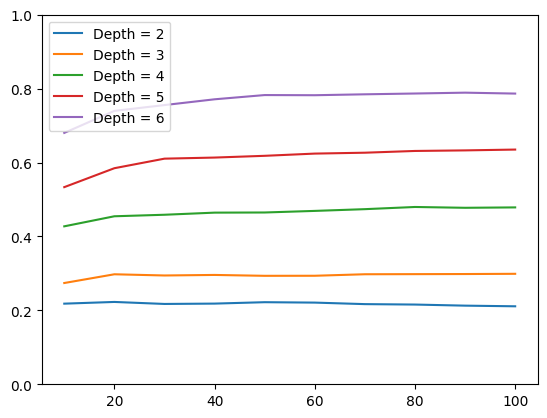

In [111]:
for depth, acc_df in learning_dfs.items():
    plt.plot(acc_df.Probabilistic, label=f"Depth = {depth}")
plt.ylim([0,1])
plt.legend()
plt.show()

In [106]:
with open("trained_rf.pkl", "wb") as f:
    pickle.dump(forests[6], f)

In [ ]:
for depth in range(7, 9):
    print(f"\n\nTesting for max_depth=={depth}")
    hyperparams["max_depth"] = depth
    forests[depth], learning_dfs[depth] = evaluation_learning(
        fitting_args = fitting_args,
        hyperparams = hyperparams,
        tree_increment = 10,
        n_increments = 10
    )
    print(learning_dfs[depth])